In [12]:
from pathlib import Path
import shutil


Path("../data/raw").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../figures").mkdir(parents=True, exist_ok=True)


old_path = Path("data:raw:price_history_checks_mar2026.csv")


new_path = Path("../data/raw/price_history_checks_mar2026.csv")


shutil.move(str(old_path), str(new_path))

print("Moved file to:", new_path)

Moved file to: ../data/raw/price_history_checks_mar2026.csv


In [13]:
import pandas as pd
from pathlib import Path

raw_path = Path("../data/raw/price_history_checks_mar2026.csv")

df = pd.read_csv(raw_path)

print(df.shape)
df.head()

(147137, 8)


,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,E10,2026-03-01 00:05:26,194.9
1,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,U91,2026-03-01 00:05:26,196.9
2,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,P95,2026-03-01 00:05:26,209.9
3,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,P98,2026-03-01 00:05:26,219.9
4,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,E85,2026-03-01 00:05:26,194.9


In [14]:
df.columns

Index(['ServiceStationName', 'Address', 'Suburb', 'Postcode', 'Brand',
       'FuelCode', 'PriceUpdatedDate', 'Price'],
      dtype='object')

In [15]:
df_clean = df.copy()

df_clean["PriceUpdatedDate"] = pd.to_datetime(df_clean["PriceUpdatedDate"], errors="coerce")
df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")

df_clean = df_clean.dropna(subset=["PriceUpdatedDate", "Price"])

df_clean["date"] = df_clean["PriceUpdatedDate"].dt.date

df_clean.head()

,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,date
0,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,E10,2026-03-01 00:05:26,194.9,2026-03-01
1,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,U91,2026-03-01 00:05:26,196.9,2026-03-01
2,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,P95,2026-03-01 00:05:26,209.9,2026-03-01
3,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,P98,2026-03-01 00:05:26,219.9,2026-03-01
4,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,E85,2026-03-01 00:05:26,194.9,2026-03-01


In [16]:
df_clean["FuelCode"].value_counts().head(20)

U91    28770
P98    28632
PDL    28367
E10    22763
P95    19161
DL     19059
LPG      202
E85      179
B20        4
Name: FuelCode, dtype: int64

In [18]:
fuel_code = "U91"

In [19]:
sydney = df_clean[
    (df_clean["Postcode"] >= 2000) &
    (df_clean["Postcode"] <= 2234)
].copy()

print(sydney.shape)
sydney[["Suburb", "Postcode"]].drop_duplicates().head(20)

(41643, 9)


,Suburb,Postcode
0,YAGOONA,2199
8,BLAKEHURST,2221
11,Belmore,2192
20,Oatley,2223
42,AUSTRAL,2179
48,WEST HOXTON,2171
53,Dulwich Hill,2203
90,Parramatta,2150
93,Turramurra,2074
95,Haberfield,2045


In [20]:
sydney_u91 = sydney[sydney["FuelCode"] == "U91"].copy()

print(sydney_u91.shape)
sydney_u91.head()

(7006, 9)


,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,date
1,Astron Yagoona,"45 ROOKWOOD RD, YAGOONA NSW 2199",YAGOONA,2199,ASTRON,U91,2026-03-01 00:05:26,196.9,2026-03-01
9,Metro Petroleum South Hurstville,"928-930 KING GEORGES RD, BLAKEHURST NSW 2221",BLAKEHURST,2221,Metro Fuel,U91,2026-03-01 02:26:11,165.9,2026-03-01
12,Metro Belmore,"607 Canterbury Road, Belmore NSW 2192",Belmore,2192,Metro Fuel,U91,2026-03-01 04:26:26,199.7,2026-03-01
21,Budget Oatley,"12B Oatley Parade, Oatley NSW 2223",Oatley,2223,Budget,U91,2026-03-01 04:52:48,179.9,2026-03-01
43,SPEEDWAY AUSTRAL,"394 FIFTEENTH AV, AUSTRAL NSW 2179",AUSTRAL,2179,Speedway,U91,2026-03-01 05:55:55,199.9,2026-03-01


In [21]:
daily_avg = (
    sydney_u91
    .groupby("date", as_index=False)
    .agg(
        average_price_cpl=("Price", "mean"),
        station_count=("ServiceStationName", "nunique")
    )
)

daily_avg.head()

,date,average_price_cpl,station_count
0,2026-03-01,190.396732,122
1,2026-03-02,187.692459,207
2,2026-03-03,206.552020,449
3,2026-03-04,202.783007,194
4,2026-03-05,208.403371,141


In [23]:
processed_path = Path("../data/processed/sydney_u91_daily_average_mar2026.csv")
daily_avg.to_csv(processed_path, index=False)

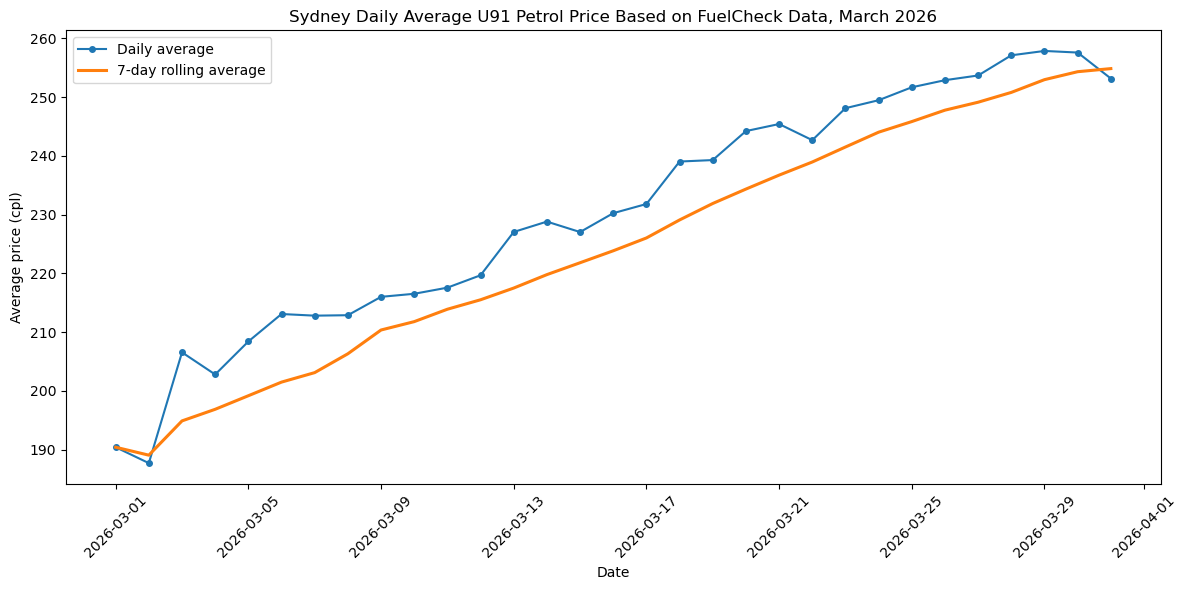

,date,average_price_cpl,station_count,observation_count,rolling_7d_avg
0,2026-03-01,190.396732,122,153,190.396732
1,2026-03-02,187.692459,207,305,189.044596
2,2026-03-03,206.552020,449,594,194.880404
3,2026-03-04,202.783007,194,306,196.856054
4,2026-03-05,208.403371,141,178,199.165518


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load raw data
raw_path = Path("../data/raw/price_history_checks_mar2026.csv")
df = pd.read_csv(raw_path)

# 2. Clean columns
df_clean = df.copy()

df_clean["PriceUpdatedDate"] = pd.to_datetime(df_clean["PriceUpdatedDate"], errors="coerce")
df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")
df_clean["Postcode"] = pd.to_numeric(df_clean["Postcode"], errors="coerce")

df_clean = df_clean.dropna(subset=["PriceUpdatedDate", "Price", "Postcode"])
df_clean["date"] = df_clean["PriceUpdatedDate"].dt.date

# 3. Filter Sydney metro and U91
sydney_u91 = df_clean[
    (df_clean["Postcode"] >= 2000) &
    (df_clean["Postcode"] <= 2234) &
    (df_clean["FuelCode"] == "U91")
].copy()

# 4. Create daily average dataset
daily_avg = (
    sydney_u91
    .groupby("date", as_index=False)
    .agg(
        average_price_cpl=("Price", "mean"),
        station_count=("ServiceStationName", "nunique"),
        observation_count=("Price", "count")
    )
)

# 5. Save processed CSV
Path("../data/processed").mkdir(parents=True, exist_ok=True)
processed_path = Path("../data/processed/sydney_u91_daily_average_mar2026.csv")
daily_avg.to_csv(processed_path, index=False)

# 6. Create rolling average
daily_avg["date"] = pd.to_datetime(daily_avg["date"])
daily_avg["rolling_7d_avg"] = daily_avg["average_price_cpl"].rolling(window=7, min_periods=1).mean()

# 7. Plot
Path("../figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_avg["date"],
    daily_avg["average_price_cpl"],
    marker="o",
    linewidth=1.5,
    markersize=4,
    label="Daily average"
)

plt.plot(
    daily_avg["date"],
    daily_avg["rolling_7d_avg"],
    linewidth=2.2,
    label="7-day rolling average"
)

plt.title("Sydney Daily Average U91 Petrol Price Based on FuelCheck Data, March 2026")
plt.xlabel("Date")
plt.ylabel("Average price (cpl)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

output_path = Path("../figures/sydney_u91_daily_average_mar2026.png")
plt.savefig(output_path, dpi=300)
plt.show()

daily_avg.head()